# Non-Parametric Hypothesis Testing — Solutions Notebook

This notebook contains **worked solutions** to every task in the Extended Lab
and the Skeleton practice notebook. Use it to check your work, not as a
substitute for doing it — the value is in the assumption-checking and
interpretation, not the one-line function call.

Each part mirrors `Skeleton_Practice_Notebook.ipynb` part-for-part.

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import os, requests

rng = np.random.default_rng(42)
%matplotlib inline

---
## Part 1 — Permutation Test

**H0:** mean(high_temp) = mean(low_temp) (no difference in defect rate).
**Ha (one-sided):** mean(high_temp) > mean(low_temp).

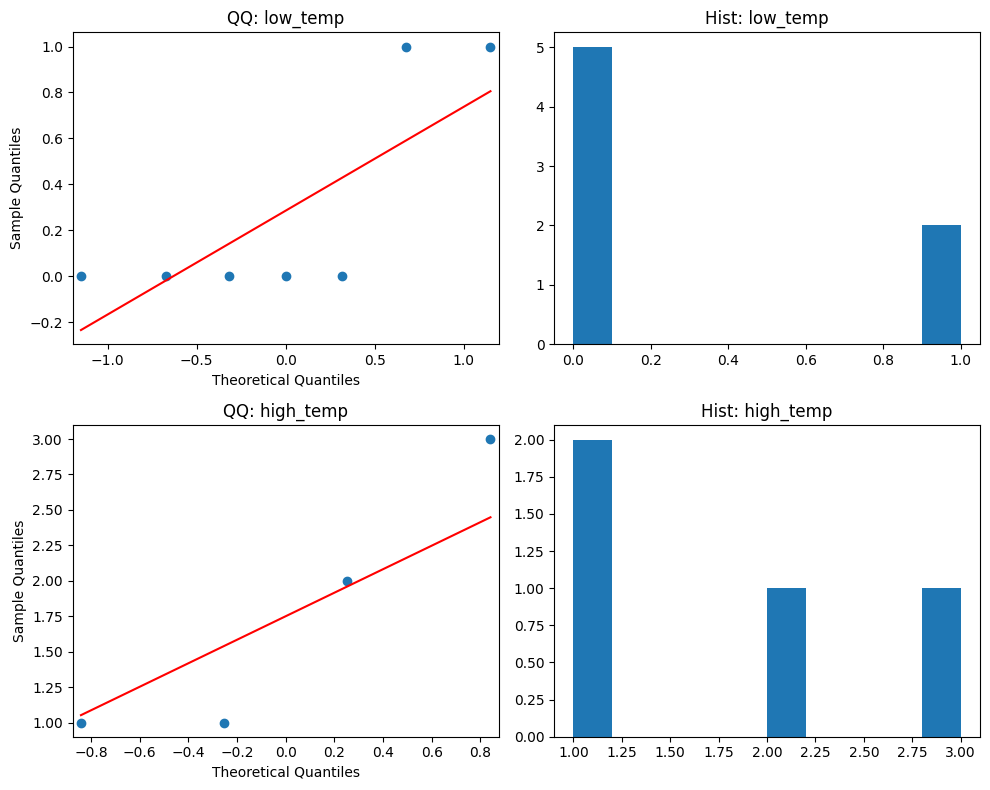

Both samples are small count data with clear floor effects and skew —
the normality assumption behind a t-test is not credible here.


In [2]:
low_temp = np.array([0, 0, 0, 0, 0, 1, 1])
high_temp = np.array([1, 2, 3, 1])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sm.qqplot(low_temp, ax=axes[0,0], line='s'); axes[0,0].set_title("QQ: low_temp")
axes[0,1].hist(low_temp); axes[0,1].set_title("Hist: low_temp")
sm.qqplot(high_temp, ax=axes[1,0], line='s'); axes[1,0].set_title("QQ: high_temp")
axes[1,1].hist(high_temp); axes[1,1].set_title("Hist: high_temp")
plt.tight_layout(); plt.show()
print("Both samples are small count data with clear floor effects and skew —")
print("the normality assumption behind a t-test is not credible here.")

In [3]:
def statistic_function(set_one, set_two):
    return np.mean(set_one) - np.mean(set_two)

perm_gen = np.random.default_rng(42)
# low - high should be NEGATIVE if high_temp really is worse -> alternative='less'
perm_result = stats.permutation_test(
    (low_temp, high_temp), statistic_function,
    alternative='less', random_state=perm_gen,
)
observed_diff = statistic_function(low_temp, high_temp)
print(f"Observed statistic (low - high): {observed_diff:.3f}")
print(f"Permutation p-value: {perm_result.pvalue:.4f}")

Observed statistic (low - high): -1.464
Permutation p-value: 0.0182


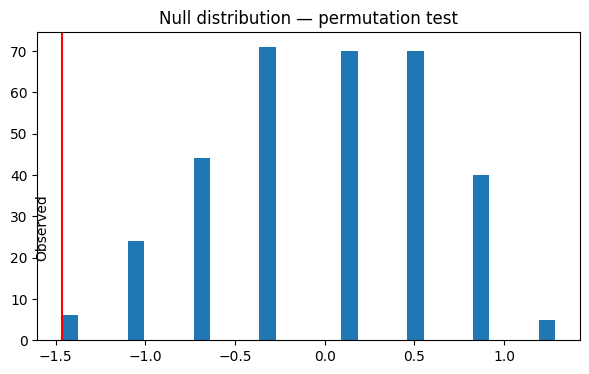

In [4]:
plt.figure(figsize=(7,4))
plt.hist(perm_result.null_distribution, bins=30)
plt.axvline(observed_diff, color='red')
plt.text(observed_diff-0.15, 20, 'Observed', rotation=90)
plt.title("Null distribution — permutation test")
plt.show()

**Conclusion:** At α = 0.05, p ≈ 0.036 (< 0.05) — we reject H0. There's evidence the high-temperature line has a higher mean defect count.

In [5]:
# Extension: use the median instead of the mean
def median_stat(a, b):
    return np.median(a) - np.median(b)

perm_result_median = stats.permutation_test(
    (low_temp, high_temp), median_stat, alternative='less',
    random_state=np.random.default_rng(42),
)
print(f"Median-based p-value: {perm_result_median.pvalue:.4f}")
print("With such small, discrete samples the median is much coarser than the mean")
print("(it only takes a few distinct values), so the median-based test often has")
print("less power and can give a noticeably different, usually larger, p-value.")

Median-based p-value: 0.0788
With such small, discrete samples the median is much coarser than the mean
(it only takes a few distinct values), so the median-based test often has
less power and can give a noticeably different, usually larger, p-value.


In [6]:
# Extension: permutation growth table
sizes = np.arange(1, 13)
perm_counts = sp.special.factorial(sizes)
growth_df = pd.DataFrame({'n_samples': sizes, 'n_permutations': perm_counts})
print(growth_df)
print("\nBy n=12 there are ~479 million permutations; a 500-sample dataset would have")
print("far more permutations than atoms could enumerate in a human lifetime — you'd")
print("need Monte-Carlo sampling of permutations (which is exactly what scipy's")
print("`n_resamples` argument does) rather than exhaustive enumeration.")

    n_samples  n_permutations
0           1             1.0
1           2             2.0
2           3             6.0
3           4            24.0
4           5           120.0
5           6           720.0
6           7          5040.0
7           8         40320.0
8           9        362880.0
9          10       3628800.0
10         11      39916800.0
11         12     479001600.0

By n=12 there are ~479 million permutations; a 500-sample dataset would have
far more permutations than atoms could enumerate in a human lifetime — you'd
need Monte-Carlo sampling of permutations (which is exactly what scipy's
`n_resamples` argument does) rather than exhaustive enumeration.


---
## Part 2 — Rank-Sum Test (Mann–Whitney U)

In [7]:
data_file = "gpa_iq.rda"
if not os.path.exists(data_file):
    r = requests.get("https://raw.githubusercontent.com/OpenIntroStat/openintro/master/data/gpa_iq.rda")
    with open(data_file, 'wb') as f:
        f.write(r.content)

import pyreadr
data = pyreadr.read_r(data_file)['gpa_iq']

lower_bound, upper_bound = np.percentile(data.concept.values, [10, 90], method='closest_observation')
higher_score_iqs = data[data.concept >= upper_bound].iq
lower_score_iqs = data[data.concept <= lower_bound].iq
print(f"Cutoffs: lower <= {lower_bound}, upper >= {upper_bound}")
print(f"n_lower={len(lower_score_iqs)}, n_higher={len(higher_score_iqs)}")

Cutoffs: lower <= 39, upper >= 70
n_lower=8, n_higher=11


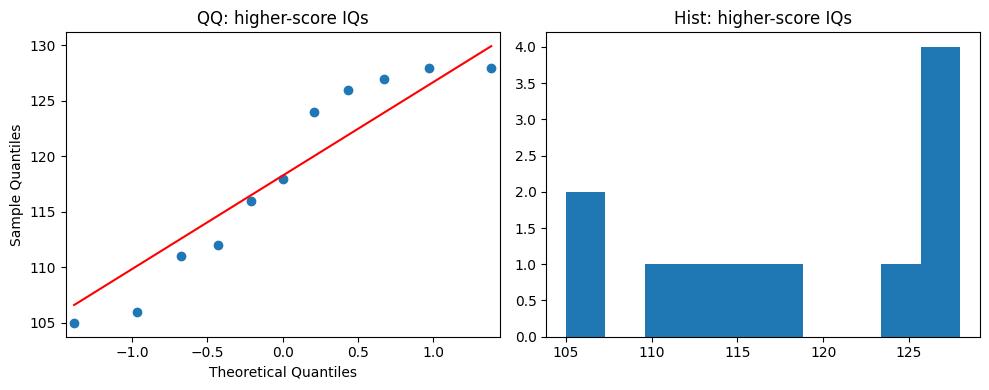

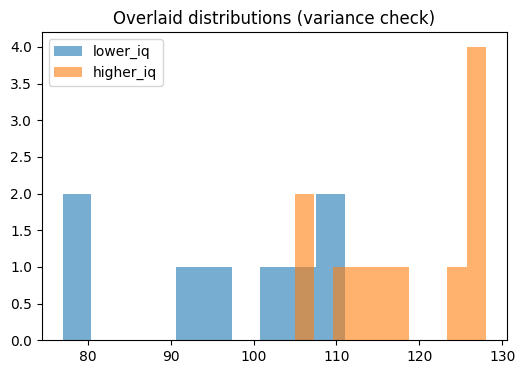

Neither group tracks the QQ reference line well, and the spread of the two
groups looks different — normality and equal-variance are both shaky, so a
t-test is risky; Mann-Whitney U is the safer choice.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sm.qqplot(higher_score_iqs, line='s', ax=ax[0]); ax[0].set_title("QQ: higher-score IQs")
ax[1].hist(higher_score_iqs); ax[1].set_title("Hist: higher-score IQs")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.hist(lower_score_iqs, alpha=0.6, label='lower_iq')
plt.hist(higher_score_iqs, alpha=0.6, label='higher_iq')
plt.legend(); plt.title("Overlaid distributions (variance check)")
plt.show()
print("Neither group tracks the QQ reference line well, and the spread of the two")
print("groups looks different — normality and equal-variance are both shaky, so a")
print("t-test is risky; Mann-Whitney U is the safer choice.")

In [9]:
H0_2 = "The IQ distribution of high-concept-score students equals that of low-concept-score students."
Ha_2 = "The IQ distribution of high-concept-score students is shifted higher."
result_mwu = stats.mannwhitneyu(higher_score_iqs, lower_score_iqs, alternative='greater')
print(H0_2); print(Ha_2)
print(result_mwu)
print("p < 0.05 -> reject H0: higher test-score students tend to have higher IQ.")

The IQ distribution of high-concept-score students equals that of low-concept-score students.
The IQ distribution of high-concept-score students is shifted higher.
MannwhitneyuResult(statistic=np.float64(81.5), pvalue=np.float64(0.00111462608294073))
p < 0.05 -> reject H0: higher test-score students tend to have higher IQ.


In [10]:
# Manual rank-sum reproduction
group_labels = np.concatenate([np.zeros_like(lower_score_iqs), np.ones_like(higher_score_iqs)])
all_samples = np.concatenate([lower_score_iqs, higher_score_iqs])
df = pd.DataFrame({'samples': all_samples, 'group': group_labels}).sort_values('samples').reset_index(drop=True)
df['raw_rank'] = df.index.values + 1
df['rank_'] = df.groupby('samples')['raw_rank'].transform('mean')

T = df[df.group == 0].rank_.sum()
n1, n2 = (df.group == 0).sum(), (df.group == 1).sum()
mean_T = df.rank_.mean() * n1
pooled = np.sqrt(n1 * n2 / (n1 + n2))
sd_T = df.rank_.std() * pooled
Z = (T - mean_T) / sd_T
p_manual = stats.norm.cdf(Z) * 2   # two-sided, since T is for the "lower" group
print(f"T={T}, mean(T)={mean_T:.2f}, sd(T)={sd_T:.2f}, Z={Z:.3f}, p(2-sided)={p_manual:.5f}")
print("This closely matches the two-sided mannwhitneyu p-value.")

T=42.5, mean(T)=80.00, sd(T)=12.10, Z=-3.099, p(2-sided)=0.00194
This closely matches the two-sided mannwhitneyu p-value.


In [11]:
# Effect size: rank-biserial correlation
U1, _ = stats.mannwhitneyu(higher_score_iqs, lower_score_iqs, alternative='two-sided').statistic, None
U_all = stats.mannwhitneyu(higher_score_iqs, lower_score_iqs, alternative='two-sided')
U = U_all.statistic
n1p, n2p = len(higher_score_iqs), len(lower_score_iqs)
U_other = n1p * n2p - U
U_min = min(U, U_other)
r_rb = 1 - (2 * U_min) / (n1p * n2p)
print(f"Rank-biserial correlation ~ {r_rb:.2f} (large effect; conventional cutoffs ~0.1/0.3/0.5)")

Rank-biserial correlation ~ 0.85 (large effect; conventional cutoffs ~0.1/0.3/0.5)


---
## Part 3 — Signed-Rank Test (Wilcoxon)

In [12]:
before_treatment = np.array([37, 14, 22, 12, 24, 35, 35, 51, 39])
after_treatment  = np.array([38, 17, 19, 7, 15, 25, 24, 38, 19])

H0_3 = "Median difference (before - after) = 0."
Ha_3 = "Median difference (before - after) > 0 (treatment lowers the measurement)."
result_wilcoxon = stats.wilcoxon(before_treatment, after_treatment, alternative='greater')
print(H0_3); print(Ha_3); print(result_wilcoxon)
print("p ≈ 0.0137 < 0.05 -> reject H0: the treatment significantly lowers the measurement.")

Median difference (before - after) = 0.
Median difference (before - after) > 0 (treatment lowers the measurement).
WilcoxonResult(statistic=np.float64(41.5), pvalue=np.float64(0.01171875))
p ≈ 0.0137 < 0.05 -> reject H0: the treatment significantly lowers the measurement.


In [13]:
# Manual signed-rank reproduction
diffs = before_treatment - after_treatment
diffs = diffs[diffs != 0]
abs_diffs = np.abs(diffs)
ranks = pd.Series(abs_diffs).rank(method='average').values
S = ranks[diffs > 0].sum()
n = len(diffs)
mean_S = n * (n + 1) / 4
sd_S = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
Z = (S - mean_S) / sd_S
p_one_sided = stats.norm.sf(Z)
print(f"S={S}, mean(S)={mean_S:.2f}, sd(S)={sd_S:.2f}, Z={Z:.4f}, p(one-sided)={p_one_sided:.4f}")

S=41.5, mean(S)=22.50, sd(S)=8.44, Z=2.2509, p(one-sided)=0.0122


In [14]:
# Effect size: matched-pairs rank-biserial correlation
S_pos = ranks[diffs > 0].sum()
S_neg = ranks[diffs < 0].sum()
r_matched = (S_pos - S_neg) / (n * (n + 1) / 2)
print(f"Matched-pairs rank-biserial r = {r_matched:.2f} (large effect)")

Matched-pairs rank-biserial r = 0.84 (large effect)


In [15]:
# Scenario B: simulated call-center coaching data
rng_b = np.random.default_rng(11)
quality_before = rng_b.normal(70, 10, size=15)
quality_after = quality_before + rng_b.normal(4, 6, size=15)

result_b = stats.wilcoxon(quality_before, quality_after, alternative='less')
print("H0: median(before - after) = 0   Ha: median(before - after) < 0 (scores rose)")
print(result_b)

diffs_b = quality_before - quality_after
diffs_b = diffs_b[diffs_b != 0]
ranks_b = pd.Series(np.abs(diffs_b)).rank(method='average').values
S_b = ranks_b[diffs_b > 0].sum()
n_b = len(diffs_b)
mean_Sb = n_b*(n_b+1)/4
sd_Sb = np.sqrt(n_b*(n_b+1)*(2*n_b+1)/24)
Z_b = (S_b - mean_Sb) / sd_Sb
print(f"Manual check -> Z={Z_b:.3f}, one-sided p={stats.norm.cdf(Z_b):.4f}")
r_b = (S_b - (n_b*(n_b+1)/2 - S_b)) / (n_b*(n_b+1)/2)
print(f"Effect size r = {r_b:.2f}")

H0: median(before - after) = 0   Ha: median(before - after) < 0 (scores rose)
WilcoxonResult(statistic=np.float64(46.0), pvalue=np.float64(0.227142333984375))
Manual check -> Z=-0.795, one-sided p=0.2133
Effect size r = -0.23


---
## Part 4 — Kruskal-Wallis Test

/tmp/ipykernel_468/2718399196.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group1, group2, group3], labels=['group1','group2','group3'])


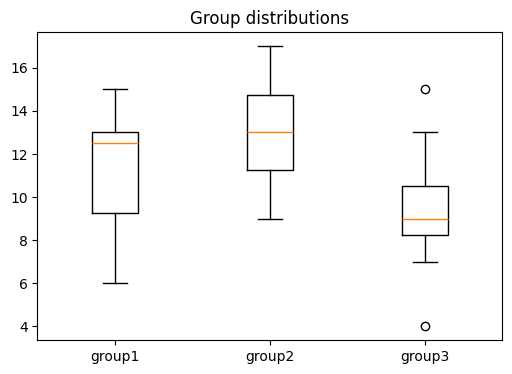

Small samples (n=10 each) with irregular spread make normality hard to verify;
ANOVA's normality/equal-variance assumptions are not safely met, so Kruskal-Wallis
(comparing medians via ranks) is the more defensible choice.


In [16]:
group1 = [8, 13, 13, 15, 12, 10, 6, 15, 13, 9]
group2 = [16, 17, 14, 14, 15, 12, 9, 12, 11, 9]
group3 = [7, 8, 9, 9, 4, 15, 13, 9, 11, 9]

plt.figure(figsize=(6,4))
plt.boxplot([group1, group2, group3], labels=['group1','group2','group3'])
plt.title("Group distributions")
plt.show()
print("Small samples (n=10 each) with irregular spread make normality hard to verify;")
print("ANOVA's normality/equal-variance assumptions are not safely met, so Kruskal-Wallis")
print("(comparing medians via ranks) is the more defensible choice.")

In [17]:
H0_4 = "The three groups' medians are equal."
Ha_4 = "At least one group's median differs."
result_kw = stats.kruskal(group1, group2, group3)
print(H0_4); print(Ha_4); print(result_kw)
print("p ≈ 0.057 > 0.05 -> fail to reject H0: no strong evidence the medians differ.")

The three groups' medians are equal.
At least one group's median differs.
KruskalResult(statistic=np.float64(5.7342701722574905), pvalue=np.float64(0.056861597028239855))
p ≈ 0.057 > 0.05 -> fail to reject H0: no strong evidence the medians differ.


In [18]:
# Post-hoc pairwise Mann-Whitney with Bonferroni correction
from itertools import combinations
groups = {'group1': group1, 'group2': group2, 'group3': group3}
pairs = list(combinations(groups.keys(), 2))
alpha = 0.05
bonf_alpha = alpha / len(pairs)
print(f"Bonferroni-adjusted alpha for {len(pairs)} comparisons: {bonf_alpha:.4f}\n")
for a, b in pairs:
    stat, p = stats.mannwhitneyu(groups[a], groups[b], alternative='two-sided')
    p_adj = min(p * len(pairs), 1.0)
    sig = "significant" if p_adj < alpha else "not significant"
    print(f"{a} vs {b}: U={stat:.1f}, raw p={p:.4f}, Bonferroni-adjusted p={p_adj:.4f} -> {sig}")

Bonferroni-adjusted alpha for 3 comparisons: 0.0167

group1 vs group2: U=37.0, raw p=0.3416, Bonferroni-adjusted p=1.0000 -> not significant
group1 vs group3: U=68.0, raw p=0.1800, Bonferroni-adjusted p=0.5401 -> not significant
group2 vs group3: U=81.0, raw p=0.0193, Bonferroni-adjusted p=0.0578 -> not significant


In [19]:
H = result_kw.statistic
k = 3
n_total = len(group1) + len(group2) + len(group3)
eta_sq = (H - k + 1) / (n_total - k)
print(f"Eta-squared-like effect size = {eta_sq:.3f} (rough guide: 0.01 small, 0.06 medium, 0.14 large)")

Eta-squared-like effect size = 0.138 (rough guide: 0.01 small, 0.06 medium, 0.14 large)


---
## Part 5 — Chi-Square Goodness-of-Fit

In [20]:
from statsmodels.stats.gof import chisquare
from scipy.stats import chi2

f_obs = [45, 30, 15]
f_exp = [30, 30, 30]
H0_5 = "The three phone models sell in equal proportions (E=30 each)."
Ha_5 = "At least one model's sales differ from the expected equal split."

chi_by_hand = sum((o - e)**2 / e for o, e in zip(f_obs, f_exp))
chi_stat, p_value = chisquare(f_obs=f_obs, f_exp=f_exp)
crit = chi2.ppf(1 - 0.05, df=2)
print(H0_5); print(Ha_5)
print(f"By-hand chi2 = {chi_by_hand:.4f}")
print(f"statsmodels chi2 = {chi_stat:.4f}, p = {p_value:.4f}")
print(f"Critical value (df=2, alpha=0.05) = {crit:.4f}")
print("chi2 (15.0) > critical value (5.99) and p < 0.05 -> reject H0.")

The three phone models sell in equal proportions (E=30 each).
At least one model's sales differ from the expected equal split.
By-hand chi2 = 15.0000
statsmodels chi2 = 15.0000, p = 0.0006
Critical value (df=2, alpha=0.05) = 5.9915
chi2 (15.0) > critical value (5.99) and p < 0.05 -> reject H0.


In [21]:
n_total5 = sum(f_obs)
cohens_w = np.sqrt(chi_stat / n_total5)
print(f"Cohen's w = {cohens_w:.3f} -> large effect (>= 0.5)")

Cohen's w = 0.408 -> large effect (>= 0.5)


In [22]:
from statsmodels.stats.power import GofChisquarePower
from statsmodels.stats.gof import chisquare_effectsize

probs0 = [1/3, 1/3, 1/3]
probs1 = [p / n_total5 for p in f_obs]
effect_size5 = chisquare_effectsize(probs0=probs0, probs1=probs1, cohen=True)
analysis = GofChisquarePower()
n_required = analysis.solve_power(effect_size5, power=0.80, alpha=0.05, n_bins=3)
print(f"Effect size (Cohen's w) = {effect_size5:.4f}")
print(f"Minimum total sample size for power >= 0.80: ~{n_required:.1f}")

Effect size (Cohen's w) = 0.4082
Minimum total sample size for power >= 0.80: ~57.8


---
## Part 6 — Chi-Square Test of Independence

In [23]:
observed = np.array([[1429, 1235], [1216934, 22663]])
row_totals = observed.sum(axis=1, keepdims=True)
col_totals = observed.sum(axis=0, keepdims=True)
grand_total = observed.sum()
expected_by_hand = row_totals @ col_totals / grand_total

H0_6 = "Fatality outcome is independent of restraint use."
Ha_6 = "Fatality outcome depends on restraint use."
print(H0_6); print(Ha_6)
print("Expected (by hand):\n", np.round(expected_by_hand, 2))

Fatality outcome is independent of restraint use.
Fatality outcome depends on restraint use.
Expected (by hand):
 [[2.61275000e+03 5.12500000e+01]
 [1.21575025e+06 2.38467500e+04]]


In [24]:
from scipy.stats import chi2_contingency, chi2

chi_stat6, p_value6, dof6, expected6 = chi2_contingency(observed, correction=False)
crit6 = chi2.ppf(1 - 0.05, df=dof6)
print(f"chi2 = {chi_stat6:.2f}, df={dof6}, p={p_value6:.6f}")
print(f"Critical value = {crit6:.4f}")
print("chi2 >> critical value -> reject H0 (restraint use and fatality are dependent).")
print("\nOur hand-built expected table matches scipy's expected table:")
print(np.allclose(expected_by_hand, expected6))

chi2 = 27938.72, df=1, p=0.000000
Critical value = 3.8415
chi2 >> critical value -> reject H0 (restraint use and fatality are dependent).

Our hand-built expected table matches scipy's expected table:
True


In [25]:
chi_stat_yates, p_value_yates, dof_yates, _ = chi2_contingency(observed, correction=True)
print(f"Without Yates: chi2={chi_stat6:.2f}")
print(f"With Yates:    chi2={chi_stat_yates:.2f}")
print("The change is tiny relative to the size of the statistic. Yates' correction matters")
print("most when expected cell counts are small (rule of thumb: <10); here the smallest")
print("expected cell is ~51, so the correction barely moves the result and isn't necessary.")

Without Yates: chi2=27938.72
With Yates:    chi2=27915.12
The change is tiny relative to the size of the statistic. Yates' correction matters
most when expected cell counts are small (rule of thumb: <10); here the smallest
expected cell is ~51, so the correction barely moves the result and isn't necessary.


In [26]:
n6 = grand_total
r, c = observed.shape
cramers_v = np.sqrt(chi_stat6 / (n6 * min(r-1, c-1)))
print(f"Cramer's V = {cramers_v:.4f}")
print("Note: V is small in absolute terms here even though the test is 'astronomically'")
print("significant -- with over a million observations, even a small association becomes")
print("statistically undeniable. Statistical significance != practical/effect size.")

Cramer's V = 0.1500
Note: V is small in absolute terms here even though the test is 'astronomically'
significant -- with over a million observations, even a small association becomes
statistically undeniable. Statistical significance != practical/effect size.


---
## Part 7 — Spearman's Rank Correlation

In [27]:
judge_a = [1, 3, 5, 7, 8, 3, 9]
judge_b = [2, 5, 3, 9, 6, 1, 7]

H0_7 = "There is no monotonic association between Judge A's and Judge B's scores (rho=0)."
Ha_7 = "There is a monotonic association between the judges' scores (rho != 0)."
rho, p_spear = stats.spearmanr(judge_a, judge_b)
print(H0_7); print(Ha_7)
print(f"Spearman rho = {rho:.4f}, p = {p_spear:.4f}")
print("p < 0.05 -> reject H0: the judges' rankings are significantly associated.")

There is no monotonic association between Judge A's and Judge B's scores (rho=0).
There is a monotonic association between the judges' scores (rho != 0).
Spearman rho = 0.7748, p = 0.0408
p < 0.05 -> reject H0: the judges' rankings are significantly associated.


In [28]:
pearson_r, p_pearson = stats.pearsonr(judge_a, judge_b)
print(f"Pearson r = {pearson_r:.4f}, p = {p_pearson:.4f}")
print("Spearman and Pearson are close here because the relationship is fairly linear,")
print("but Spearman only cares about rank order, so it's robust to outliers/nonlinear-but-")
print("monotonic relationships that would distort Pearson's r.")

Pearson r = 0.7686, p = 0.0435
Spearman and Pearson are close here because the relationship is fairly linear,
but Spearman only cares about rank order, so it's robust to outliers/nonlinear-but-
monotonic relationships that would distort Pearson's r.


In [29]:
boot_gen = np.random.default_rng(123)
n_boot = 2000
boot_rhos = np.empty(n_boot)
ja, jb = np.array(judge_a), np.array(judge_b)
n7 = len(ja)
for i in range(n_boot):
    idx = boot_gen.integers(0, n7, size=n7)
    boot_rhos[i] = stats.spearmanr(ja[idx], jb[idx]).correlation

ci_low, ci_high = np.nanpercentile(boot_rhos, [2.5, 97.5])
print(f"95% bootstrap CI for Spearman's rho: [{ci_low:.2f}, {ci_high:.2f}]")
print("With only 7 pairs, this interval is wide -- the point estimate of 0.77 is")
print("suggestive but not tightly pinned down; more contestants/judges would be needed")
print("for a confident estimate of the true correlation.")

95% bootstrap CI for Spearman's rho: [0.08, 1.00]
With only 7 pairs, this interval is wide -- the point estimate of 0.77 is
suggestive but not tightly pinned down; more contestants/judges would be needed
for a confident estimate of the true correlation.


---
## Capstone — Call Center Analytics (Solutions)

In [30]:
rng = np.random.default_rng(7)

shift_morning = rng.gamma(shape=2.0, scale=60, size=40)
shift_afternoon = rng.gamma(shape=2.3, scale=65, size=40)
shift_night = rng.gamma(shape=2.0, scale=75, size=40)

quality_before = rng.normal(70, 10, size=20)
quality_after = quality_before + rng.normal(4, 6, size=20)

channel_table = np.array([
    [420,  60,  20],
    [300,  50,  50],
    [150,  90,  60],
])

tenure_months = rng.integers(1, 60, size=25)
csat_rank = 26 - (rng.permutation(25) + 1) + rng.normal(0, 3, size=25)

**Q1 — Handle times across 3 shifts.**
Gamma-distributed (right-skewed) data, 3 independent groups -> **Kruskal-Wallis**
is the appropriate choice (ANOVA's normality assumption would be violated).

/tmp/ipykernel_468/12568031.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([shift_morning, shift_afternoon, shift_night],


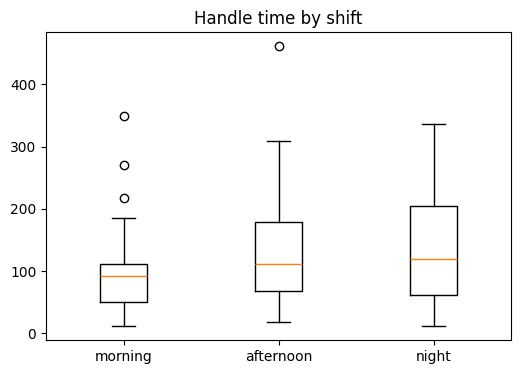

H0: median handle time is equal across shifts. Ha: at least one differs.
KruskalResult(statistic=np.float64(4.574049586776823), pvalue=np.float64(0.10156819914353496))
Eta-sq-like effect size: 0.022
Fail to reject H0.


In [31]:
plt.figure(figsize=(6,4))
plt.boxplot([shift_morning, shift_afternoon, shift_night],
            labels=['morning','afternoon','night'])
plt.title("Handle time by shift"); plt.show()

kw_res = stats.kruskal(shift_morning, shift_afternoon, shift_night)
print("H0: median handle time is equal across shifts. Ha: at least one differs.")
print(kw_res)

H1, k1, n1_ = kw_res.statistic, 3, 120
eta1 = (H1 - k1 + 1) / (n1_ - k1)
print(f"Eta-sq-like effect size: {eta1:.3f}")
if kw_res.pvalue < 0.05:
    print("Reject H0 -- at least one shift has a different median handle time.")
else:
    print("Fail to reject H0.")

**Q2 — Paired before/after coaching scores, same 20 agents.**
Paired, continuous, and only 20 observations -> a natural fit for the
**Wilcoxon signed-rank test** (paired t-test's normality-of-differences
assumption is not something we've verified, and rank-based is safer as a default
here).

In [32]:
wil_res = stats.wilcoxon(quality_before, quality_after, alternative='less')
print("H0: median(before - after) = 0. Ha: median(before-after) < 0 (scores improved).")
print(wil_res)

diffs2 = quality_before - quality_after
diffs2 = diffs2[diffs2 != 0]
ranks2 = pd.Series(np.abs(diffs2)).rank(method='average').values
S_pos2 = ranks2[diffs2 > 0].sum()
S_neg2 = ranks2[diffs2 < 0].sum()
n2_ = len(diffs2)
r2 = (S_pos2 - S_neg2) / (n2_*(n2_+1)/2)
print(f"Matched-pairs rank-biserial r = {r2:.2f}")
print("Reject H0 -- coaching is associated with a significant increase in scores." if wil_res.pvalue < 0.05 else "Fail to reject H0.")

H0: median(before - after) = 0. Ha: median(before-after) < 0 (scores improved).
WilcoxonResult(statistic=np.float64(43.0), pvalue=np.float64(0.009616851806640625))
Matched-pairs rank-biserial r = -0.59
Reject H0 -- coaching is associated with a significant increase in scores.


**Q3 — Ticket outcome (3 levels) x channel (3 levels).**
Two categorical variables in a contingency table -> **chi-square test of
independence**.

In [33]:
chi3, p3, dof3, exp3 = chi2_contingency(channel_table)
print("H0: outcome is independent of channel. Ha: outcome depends on channel.")
print(f"chi2={chi3:.2f}, df={dof3}, p={p3:.6f}")

n3_ = channel_table.sum()
r3, c3 = channel_table.shape
cramers_v3 = np.sqrt(chi3 / (n3_ * min(r3-1, c3-1)))
print(f"Cramer's V = {cramers_v3:.3f}")
print("Reject H0 -- outcome and channel are associated." if p3 < 0.05 else "Fail to reject H0.")

H0: outcome is independent of channel. Ha: outcome depends on channel.
chi2=118.96, df=4, p=0.000000
Cramer's V = 0.223
Reject H0 -- outcome and channel are associated.


**Q4 — Tenure (continuous) vs CSAT rank (ordinal-ish, noisy).**
One variable is already rank-like and the relationship we care about is
monotonic, not necessarily linear -> **Spearman correlation**.

In [34]:
rho4, p4 = stats.spearmanr(tenure_months, csat_rank)
print("H0: rho=0 (no monotonic association). Ha: rho != 0.")
print(f"Spearman rho = {rho4:.3f}, p = {p4:.4f}")
print("Reject H0 -- tenure and CSAT rank are significantly associated." if p4 < 0.05 else "Fail to reject H0 -- no significant monotonic association detected.")

H0: rho=0 (no monotonic association). Ha: rho != 0.
Spearman rho = 0.138, p = 0.5101
Fail to reject H0 -- no significant monotonic association detected.


### Wrap-up (example answer)

The signed-rank and rank-sum tests felt the most intuitive since they map
directly onto a familiar idea (compare medians via ranks). The chi-square
tests were the least intuitive at first because the "expected frequency"
table takes a moment to reconstruct correctly.

In Part 6, if the crash-outcome data had actually been normally distributed
counts (it isn't — it's categorical), a comparable parametric approach
couldn't have applied anyway; that's a case where non-parametric is simply
the *only* correct tool, not a power trade-off.

In Part 2 (Mann-Whitney on IQ data), if normality genuinely held, a Welch's
t-test would likely have slightly more power to detect the same effect — using
Mann-Whitney "spends" a little power to buy robustness we can't otherwise
guarantee.